# Stage 11 Homework — Evaluation & Risk Communication
In the lecture, we learned **gaussian-based vs bootstrap-based CIs**, **scenario sensitivity**, and **subgroup checks**.
Now, you will adapt those methods to your dataset and produce assumption-aware results.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
np.random.seed(111)
plt.rcParams['figure.figsize'] = (8,5)

## Load Data (provided or synthetic fallback)

In [3]:
from pathlib import Path
import pandas as pd
ROOT=Path.cwd()
for p in [ROOT,*ROOT.parents]:
 if (p/'project'/'data').exists(): ROOT=p; break
PROJECT_ROOT=ROOT/'project'
df=pd.read_csv(PROJECT_ROOT/'data/processed/sp500_sector_features_stage09.csv',parse_dates=['date'])
df=df.sort_values(['date','ticker']).reset_index(drop=True)
df['future_return_5d']=df.groupby('ticker')['close'].shift(-5)/df['close']-1
df.head()
df['x_feature']=df['momentum_5d']
df['y_target']=df['future_return_5d']
df['segment']=df['ticker']
df=df.dropna(subset=['x_feature','y_target']).copy()
df.head()

,date,ticker,close,momentum_5d,daily_return,rolling_mean_return_20d,sector_Communication Services,sector_Consumer Discretionary,sector_Consumer Staples,sector_Energy,...,sector_Health Care,sector_Industrials,sector_Information Technology,sector_Materials,sector_Real Estate,sector_Utilities,future_return_5d,x_feature,y_target,segment
55,2021-09-07 13:30:00,XLB,42.404999,-0.012229,-0.006560,NaN,0,0,0,0,...,0,0,0,1,0,0,-0.020516,-0.012229,-0.020516,XLB
56,2021-09-07 13:30:00,XLC,85.669998,0.004338,0.002340,NaN,1,0,0,0,...,0,0,0,0,0,0,-0.022528,0.004338,-0.022528,XLC
57,2021-09-07 13:30:00,XLE,24.165001,-0.008208,-0.005965,NaN,0,0,0,1,...,0,0,0,0,0,0,0.002483,-0.008208,0.002483,XLE
58,2021-09-07 13:30:00,XLF,37.840000,-0.015865,-0.006041,NaN,0,0,0,0,...,0,0,0,0,0,0,-0.008985,-0.015865,-0.008985,XLF
59,2021-09-07 13:30:00,XLI,102.779999,-0.019275,-0.017306,NaN,0,0,0,0,...,0,1,0,0,0,0,-0.017319,-0.019275,-0.017319,XLI


## Helper Functions (complete or modify as needed)

In [4]:
def mean_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmean(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

def median_impute(a: np.ndarray) -> np.ndarray:
    m = np.nanmedian(a)
    out = a.copy()
    out[np.isnan(out)] = m
    return out

class SimpleLinReg:
    def fit(self, X, y):
        X1 = np.c_[np.ones(len(X)), X.ravel()]
        beta = np.linalg.pinv(X1) @ y
        self.intercept_, self.coef_ = float(beta[0]), np.array([float(beta[1])])
        return self
    def predict(self, X):
        return self.intercept_ + self.coef_[0] * X.ravel()

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def bootstrap_metric(y_true, y_pred, fn, n_boot=500, seed=111, alpha=0.05):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y_true))
    stats = []
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        stats.append(fn(y_true[b], y_pred[b]))
    lo, hi = np.percentile(stats, [100*alpha/2, 100*(1-alpha/2)])
    return {'mean': float(np.mean(stats)), 'lo': float(lo), 'hi': float(hi)}

def fit_fn(X, y):
    return SimpleLinReg().fit(X, y)
def pred_fn(model, X):
    return model.predict(X)

## Baseline Fit & Residuals (Required)

In [5]:
X_raw = df['x_feature'].values
y = df['y_target'].values
X_base = mean_impute(X_raw)
model = fit_fn(X_base.reshape(-1,1), y)
y_hat = model.predict(X_base.reshape(-1,1))
df['x_imputed'] = X_base
base_mae = mae(y, y_hat)
base_mae

0.020822294146823357

## Gaussian-based vs Bootstrap-based CI (Required)

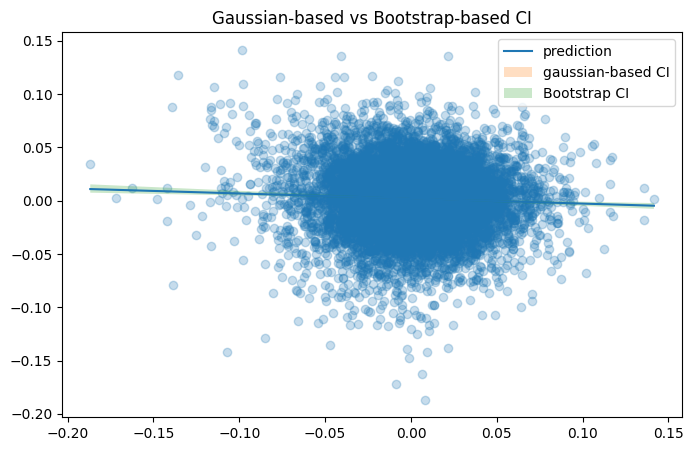

In [6]:
resid = y - y_hat
sigma_hat = np.std(resid, ddof=1)
n = len(y)
se_mean = sigma_hat/np.sqrt(n)
x_grid = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 120).reshape(-1,1)
pred_line = model.predict(x_grid)
gauss_lo = pred_line - 1.96*se_mean
gauss_hi = pred_line + 1.96*se_mean

def bootstrap_predictions(X, y, x_grid, n_boot=500, seed=111):
    rng = np.random.default_rng(seed)
    preds = []
    idx = np.arange(len(y))
    for _ in range(n_boot):
        b = rng.choice(idx, size=len(idx), replace=True)
        m = fit_fn(X[b].reshape(-1,1), y[b])
        preds.append(m.predict(x_grid))
    P = np.vstack(preds)
    return P.mean(axis=0), np.percentile(P, 2.5, axis=0), np.percentile(P, 97.5, axis=0)

m_boot, lo_boot, hi_boot = bootstrap_predictions(X_base, y, x_grid, n_boot=600)

plt.figure()
plt.scatter(X_base, y, alpha=0.25)
plt.plot(x_grid, pred_line, label='prediction')
plt.fill_between(x_grid.ravel(), gauss_lo, gauss_hi, alpha=0.25, label='gaussian-based CI')
plt.fill_between(x_grid.ravel(), lo_boot, hi_boot, alpha=0.25, label='Bootstrap CI')
plt.legend(); plt.title('Gaussian-based vs Bootstrap-based CI'); plt.show()

## Scenario Sensitivity (Required): Choose ≥2 Scenarios
Examples: mean vs median impute; drop; alternate feature transform

In [7]:
scenarios = {
    'mean_impute': mean_impute,
    'median_impute': median_impute,
    'drop_missing': lambda a: a[~np.isnan(a)] if np.isnan(a).any() else a
}

results = []
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xs, ys = X_raw[mask], y[mask]
        m = fit_fn(Xs.reshape(-1,1), ys)
        yh = m.predict(Xs.reshape(-1,1))
    else:
        Xs = fn(X_raw)
        m = fit_fn(Xs.reshape(-1,1), y)
        yh = m.predict(Xs.reshape(-1,1))
    results.append({'scenario': name, 'mae': mae(y[:len(yh)], yh), 'slope': m.coef_[0], 'intercept': m.intercept_})
sens = pd.DataFrame(results)

# Save the scenario table - this is your sensitivity
# evidence, and what your Stage 12 stakeholder report is built from.
Path('data/processed').mkdir(parents=True, exist_ok=True)
sens.to_csv('data/processed/scenario_results.csv', index=False)
sens

,scenario,mae,slope,intercept
0,mean_impute,0.020822,-0.047524,0.001994
1,median_impute,0.020822,-0.047524,0.001994
2,drop_missing,0.020822,-0.047524,0.001994


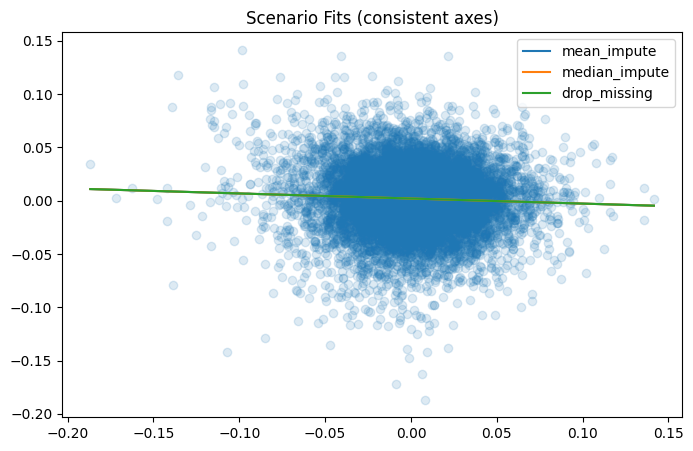

In [8]:
plt.figure()
xg = np.linspace(np.nanmin(X_base), np.nanmax(X_base), 150).reshape(-1,1)
for name, fn in scenarios.items():
    if name == 'drop_missing' and np.isnan(X_raw).any():
        mask = ~np.isnan(X_raw)
        Xi, yi = X_raw[mask], y[mask]
    else:
        Xi, yi = fn(X_raw), y
    m = fit_fn(Xi.reshape(-1,1), yi)
    plt.plot(xg, m.predict(xg), label=name)
plt.scatter(X_base, y, alpha=0.15)
plt.title('Scenario Fits (consistent axes)'); plt.legend(); plt.show()

## Subgroup Diagnostic (Required)

In [9]:
model_base = fit_fn(X_base.reshape(-1,1), y)
df2 = df.copy()
df2['y_hat'] = model_base.predict(df2['x_imputed'].values.reshape(-1,1))
df2['resid'] = df2['y_target'] - df2['y_hat']
g = df2.groupby('segment')['resid'].agg(['mean','std','median','count'])
g

,mean,std,median,count
segment,,,,
XLB,-0.000615,0.026750,-0.000283,1245
XLC,-0.000405,0.027715,0.001477,1245
XLE,0.002751,0.036939,0.004728,1245
XLF,0.000168,0.025855,0.001904,1245
XLI,0.000649,0.023896,0.001463,1245
XLK,0.002203,0.034813,0.002452,1245
XLP,-0.001073,0.018331,-0.000470,1245
XLRE,-0.001858,0.026755,-0.000627,1245
XLU,-0.000726,0.024482,0.001526,1245


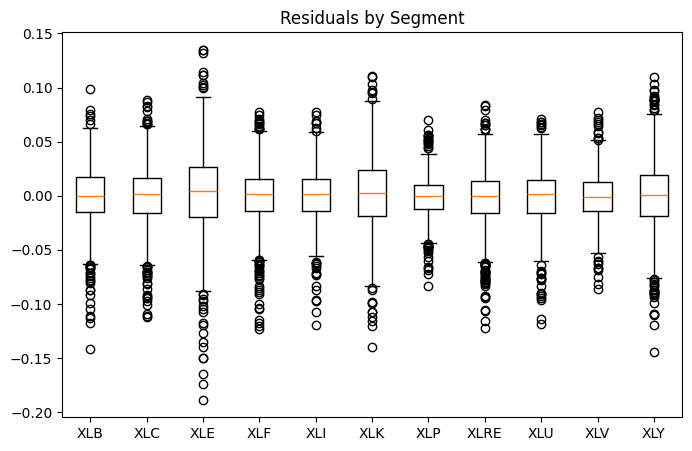

In [10]:
plt.figure()
grouped = df2.groupby('segment')['resid']
data = [s.values for _, s in grouped]
labels = list(grouped.groups.keys())

# NOT tick_labels= and NOT labels= - both spellings are version-locked. Setting the
# ticks separately works on every matplotlib.
plt.boxplot(data)
plt.xticks(range(1, len(labels) + 1), labels)
plt.title('Residuals by Segment')
plt.show()


## Bootstrap a Metric (Required)

In [11]:
bm = bootstrap_metric(y, df2['y_hat'].values, mae, n_boot=600)
bm

{'mean': 0.020825294632878612,
 'lo': 0.020486550793046867,
 'hi': 0.02112826770103362}

## Stakeholder Summary

The evaluation combines error metrics, bootstrap uncertainty, scenario comparisons, and sector-level residual checks. The model should only be trusted as a historical baseline when the data is fresh and the feature definitions are unchanged.

Predictions may fail when market regimes change or when sector behavior differs from the training period.

The model is intended for decision support, not an automatic investment rule.